In [2]:
import sys
sys.path.append('..')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import time
import pandas as pd
from collections import defaultdict

from models.transfer_models import TransferModel
from augmentation.advanced_aug import BaselineTransform, BaselineAugmentation, AdvancedAugmentation
from augmentation.advanced_aug import LabelSmoothingCrossEntropy

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [3]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    return running_loss / total, correct / total

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return running_loss / total, correct / total

class EarlyStopping:
    def __init__(self, patience=5):
        self.patience = patience
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

In [12]:
def run_experiment(model_name, augmentation_type, dropout_rate = 0.5, use_label_smoothing=False,
                   weight_decay=0, num_epochs=15, experiment_name=''):

    print(f'Experiment: {experiment_name}')
    print(f'Model: {model_name}, Augmentation: {augmentation_type}')
    print(f'Label Smoothing: {use_label_smoothing}, Weight Decay: {weight_decay}')

    data_dir = '../dataSet/archive/seg_train/seg_train'
    test_dir = '../dataSet/archive/seg_test/seg_test'
    if augmentation_type == 'baseline':
        train_transform = BaselineAugmentation.get_transforms(224)
    elif augmentation_type == 'advanced':
        train_transform = AdvancedAugmentation.get_transforms(224)

    val_transform = BaselineTransform.get_transforms(224)

    full_train = datasets.ImageFolder(data_dir, transform=train_transform)
    train_size = int(0.8 * len(full_train))
    val_size = len(full_train) - train_size
    train_dataset, _ = random_split(full_train, [train_size, val_size])

    val_dataset_full = datasets.ImageFolder(data_dir, transform=val_transform)
    _, val_dataset = random_split(val_dataset_full, [train_size, val_size])

    test_dataset = datasets.ImageFolder(test_dir, transform=val_transform)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

    model = TransferModel(model_name=model_name, num_classes=6, pretrained=True).to(device)
    model.unfreeze_last_layers_resnet()

    param_groups = model.get_resnet_param_groups(lr_layer4=0.0001, lr_head=0.001)
    optimizer = optim.Adam(param_groups, weight_decay=weight_decay)

    if dropout_rate > 0:
        from augmentation.advanced_aug import get_regularized_model
        model = get_regularized_model(model, dropout_rate=dropout_rate).to(device)
    else:
        model = model.to(device)

    if use_label_smoothing:
        criterion = LabelSmoothingCrossEntropy(smoothing=0.1)
    else:
        criterion = nn.CrossEntropyLoss()



    early_stopping = EarlyStopping(patience=3)

    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    best_val_acc = 0.0
    start_time = time.time()

    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f'Epoch [{epoch+1}/{num_epochs}] Train: {train_acc:.4f}, Val: {val_acc:.4f}')

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            Path('../checkpoints').mkdir(exist_ok=True)
            torch.save(model.state_dict(), f'../checkpoints/{experiment_name}.pth')

        early_stopping(val_loss)
        if early_stopping.early_stop:
            print(f'Early stopping at epoch {epoch+1}')
            break

    training_time = time.time() - start_time

    model.load_state_dict(torch.load(f'../checkpoints/{experiment_name}.pth'))
    test_loss, test_acc = validate(model, test_loader, criterion, device)

    overfitting = history['train_acc'][-1] - history['val_acc'][-1]

    results = {
        'experiment': experiment_name,
        'model': model_name,
        'augmentation': augmentation_type,
        'label_smoothing': use_label_smoothing,
        'weight_decay': weight_decay,
        'best_val_acc': best_val_acc,
        'test_acc': test_acc,
        'overfitting': overfitting,
        'training_time': training_time,
        'epochs_trained': len(history['train_loss']),
        'history': history
    }

    print(f'\nVal: {best_val_acc:.4f}, Test: {test_acc:.4f}, Overfitting: {overfitting:.4f}')

    return results

In [5]:
results_list = []

In [6]:
result1 = run_experiment(
    model_name='resnet18',
    augmentation_type='baseline',
    use_label_smoothing=False,
    weight_decay=0,
    dropout_rate=0,
    num_epochs=15,
    experiment_name='aug_baseline'
)
results_list.append(result1)

Experiment: aug_baseline
Model: resnet18, Augmentation: baseline
Label Smoothing: False, Weight Decay: 0


C:\Users\zhenu\anaconda3\envs\torch_gpu\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\zhenu\anaconda3\envs\torch_gpu\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/15] Train: 0.8839, Val: 0.9134
Epoch [2/15] Train: 0.9281, Val: 0.9498
Epoch [3/15] Train: 0.9402, Val: 0.9558
Epoch [4/15] Train: 0.9485, Val: 0.9647
Epoch [5/15] Train: 0.9604, Val: 0.9715
Epoch [6/15] Train: 0.9669, Val: 0.9719
Epoch [7/15] Train: 0.9700, Val: 0.9761
Epoch [8/15] Train: 0.9781, Val: 0.9804
Epoch [9/15] Train: 0.9808, Val: 0.9726
Epoch [10/15] Train: 0.9807, Val: 0.9793
Early stopping at epoch 10


C:\Users\zhenu\AppData\Local\Temp\ipykernel_1172\4218771845.py:77: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'../checkpoints/{experimen


Val: 0.9804, Test: 0.9217, Overfitting: 0.0013


In [7]:
result2 = run_experiment(
    model_name='resnet18',
    augmentation_type='advanced',
    use_label_smoothing=False,
    weight_decay=0,
    dropout_rate=0,
    num_epochs=15,
    experiment_name='aug_advanced'
)
results_list.append(result2)

Experiment: aug_advanced
Model: resnet18, Augmentation: advanced
Label Smoothing: False, Weight Decay: 0
Epoch [1/15] Train: 0.8550, Val: 0.9291
Epoch [2/15] Train: 0.9039, Val: 0.9362
Epoch [3/15] Train: 0.9182, Val: 0.9491
Epoch [4/15] Train: 0.9236, Val: 0.9501
Epoch [5/15] Train: 0.9343, Val: 0.9583
Epoch [6/15] Train: 0.9399, Val: 0.9523
Epoch [7/15] Train: 0.9427, Val: 0.9537
Epoch [8/15] Train: 0.9479, Val: 0.9612
Epoch [9/15] Train: 0.9491, Val: 0.9601
Epoch [10/15] Train: 0.9575, Val: 0.9669
Epoch [11/15] Train: 0.9546, Val: 0.9651
Early stopping at epoch 11


C:\Users\zhenu\AppData\Local\Temp\ipykernel_1172\4218771845.py:77: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'../checkpoints/{experimen


Val: 0.9669, Test: 0.9287, Overfitting: -0.0105


AUGMENTATION COMPARISON
Augmentation Val Acc Test Acc Overfitting
    Baseline  0.9804   0.9217      0.0013
    Advanced  0.9669   0.9287     -0.0105


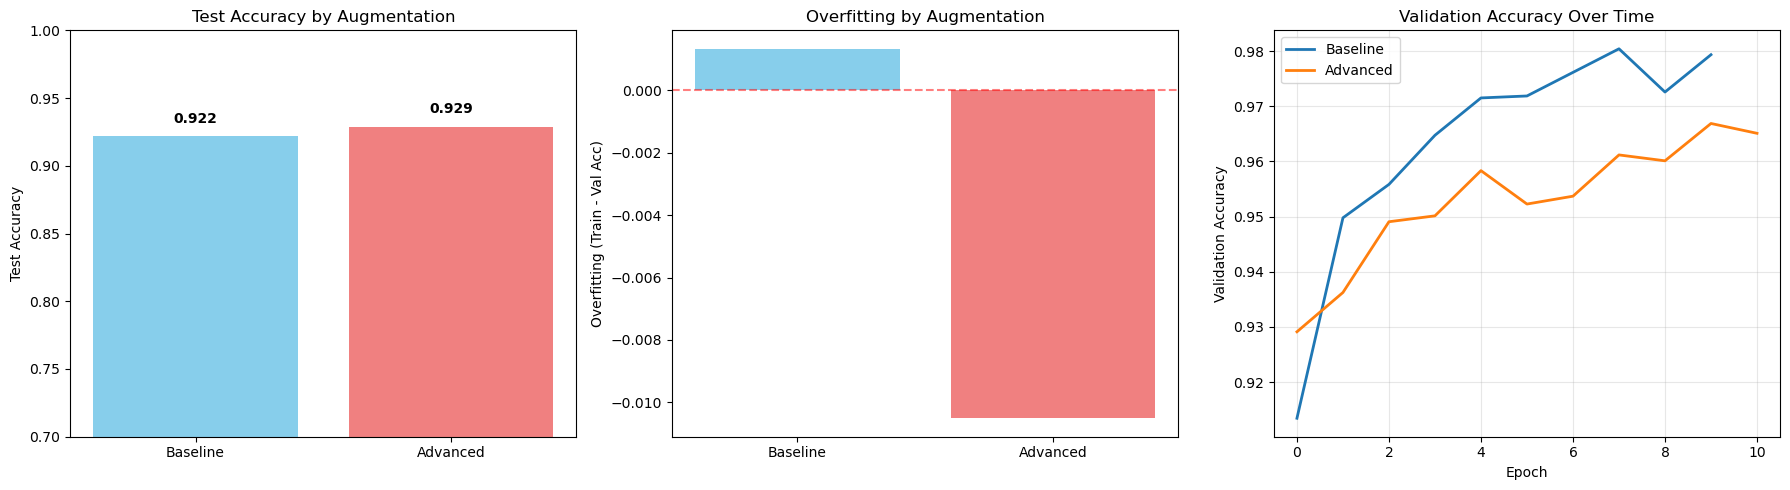

In [8]:
aug_df = pd.DataFrame([
    {
        'Augmentation': r['augmentation'].title(),
        'Val Acc': f"{r['best_val_acc']:.4f}",
        'Test Acc': f"{r['test_acc']:.4f}",
        'Overfitting': f"{r['overfitting']:.4f}"
    }
    for r in results_list[:2]
])

print('AUGMENTATION COMPARISON')
print(aug_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

names = [r['augmentation'].title() for r in results_list[:2]]
test_accs = [r['test_acc'] for r in results_list[:2]]
overfitting = [r['overfitting'] for r in results_list[:2]]

axes[0].bar(names, test_accs, color=['skyblue', 'lightcoral', 'lightgreen'])
axes[0].set_ylabel('Test Accuracy')
axes[0].set_title('Test Accuracy by Augmentation')
axes[0].set_ylim([0.7, 1.0])
for i, v in enumerate(test_accs):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

axes[1].bar(names, overfitting, color=['skyblue', 'lightcoral', 'lightgreen'])
axes[1].set_ylabel('Overfitting (Train - Val Acc)')
axes[1].set_title('Overfitting by Augmentation')
axes[1].axhline(0, color='red', linestyle='--', alpha=0.5)

for r in results_list[:2]:
    axes[2].plot(r['history']['val_acc'], label=r['augmentation'].title(), linewidth=2)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Validation Accuracy')
axes[2].set_title('Validation Accuracy Over Time')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
Path('../results').mkdir(exist_ok=True)
plt.savefig('../results/augmentation_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
result4 = run_experiment(
    model_name='resnet18',
    augmentation_type='baseline',
    use_label_smoothing=True,
    weight_decay=0,
    dropout_rate=0.5,
    num_epochs=15,
    experiment_name='reg_label_dropout_smoothing'
)
results_list.append(result4)


Experiment: reg_label_dropout_smoothing
Model: resnet18, Augmentation: baseline
Label Smoothing: True, Weight Decay: 0
Epoch [1/15] Train: 0.8590, Val: 0.9387
Epoch [2/15] Train: 0.9146, Val: 0.9451
Epoch [3/15] Train: 0.9333, Val: 0.9569
Epoch [4/15] Train: 0.9416, Val: 0.9608
Epoch [5/15] Train: 0.9504, Val: 0.9622
Epoch [6/15] Train: 0.9589, Val: 0.9704
Epoch [7/15] Train: 0.9678, Val: 0.9733
Epoch [8/15] Train: 0.9743, Val: 0.9754
Epoch [9/15] Train: 0.9805, Val: 0.9822
Epoch [10/15] Train: 0.9817, Val: 0.9825
Epoch [11/15] Train: 0.9856, Val: 0.9808
Epoch [12/15] Train: 0.9900, Val: 0.9815
Epoch [13/15] Train: 0.9899, Val: 0.9847
Epoch [14/15] Train: 0.9923, Val: 0.9861
Epoch [15/15] Train: 0.9937, Val: 0.9847


C:\Users\zhenu\AppData\Local\Temp\ipykernel_1172\4257630073.py:85: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'../checkpoints/{experimen


Val: 0.9861, Test: 0.9303, Overfitting: 0.0090


In [14]:
result5 = run_experiment(
    model_name='resnet18',
    augmentation_type='baseline',
    use_label_smoothing=False,
    weight_decay=1e-4,
    dropout_rate=0.5,
    num_epochs=15,
    experiment_name='reg_weight_dropout_decay'
)
results_list.append(result5)

Experiment: reg_weight_dropout_decay
Model: resnet18, Augmentation: baseline
Label Smoothing: False, Weight Decay: 0.0001
Epoch [1/15] Train: 0.8641, Val: 0.9327
Epoch [2/15] Train: 0.9206, Val: 0.9515
Epoch [3/15] Train: 0.9345, Val: 0.9629
Epoch [4/15] Train: 0.9447, Val: 0.9640
Epoch [5/15] Train: 0.9548, Val: 0.9629
Epoch [6/15] Train: 0.9604, Val: 0.9729
Epoch [7/15] Train: 0.9665, Val: 0.9800
Epoch [8/15] Train: 0.9710, Val: 0.9758
Epoch [9/15] Train: 0.9739, Val: 0.9711
Epoch [10/15] Train: 0.9798, Val: 0.9815
Early stopping at epoch 10


C:\Users\zhenu\AppData\Local\Temp\ipykernel_1172\4257630073.py:85: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'../checkpoints/{experimen


Val: 0.9815, Test: 0.9253, Overfitting: -0.0017


In [15]:
result6 = run_experiment(
    model_name='resnet18',
    augmentation_type='baseline',
    use_label_smoothing=True,
    weight_decay=1e-4,
    dropout_rate=0.5,
    num_epochs=15,
    experiment_name='reg_combined'
)
results_list.append(result6)

Experiment: reg_combined
Model: resnet18, Augmentation: baseline
Label Smoothing: True, Weight Decay: 0.0001
Epoch [1/15] Train: 0.8548, Val: 0.9020
Epoch [2/15] Train: 0.9139, Val: 0.9441
Epoch [3/15] Train: 0.9297, Val: 0.9562
Epoch [4/15] Train: 0.9418, Val: 0.9601
Epoch [5/15] Train: 0.9511, Val: 0.9662
Epoch [6/15] Train: 0.9592, Val: 0.9736
Epoch [7/15] Train: 0.9670, Val: 0.9751
Epoch [8/15] Train: 0.9744, Val: 0.9797
Epoch [9/15] Train: 0.9797, Val: 0.9743
Epoch [10/15] Train: 0.9816, Val: 0.9829
Epoch [11/15] Train: 0.9857, Val: 0.9804
Epoch [12/15] Train: 0.9882, Val: 0.9815
Epoch [13/15] Train: 0.9899, Val: 0.9900
Epoch [14/15] Train: 0.9925, Val: 0.9857
Epoch [15/15] Train: 0.9912, Val: 0.9890


C:\Users\zhenu\AppData\Local\Temp\ipykernel_1172\4257630073.py:85: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'../checkpoints/{experimen


Val: 0.9900, Test: 0.9330, Overfitting: 0.0022


REGULARIZATION COMPARISON
           Method Label Smoothing Weight Decay Val Acc Test Acc Overfitting
Advanced Aug Only              No            0  0.9669   0.9287     -0.0105
+ Label Smoothing             Yes            0  0.9861   0.9303      0.0090
   + Weight Decay              No         1e-4  0.9815   0.9253     -0.0017
           + Both             Yes         1e-4  0.9900   0.9330      0.0022


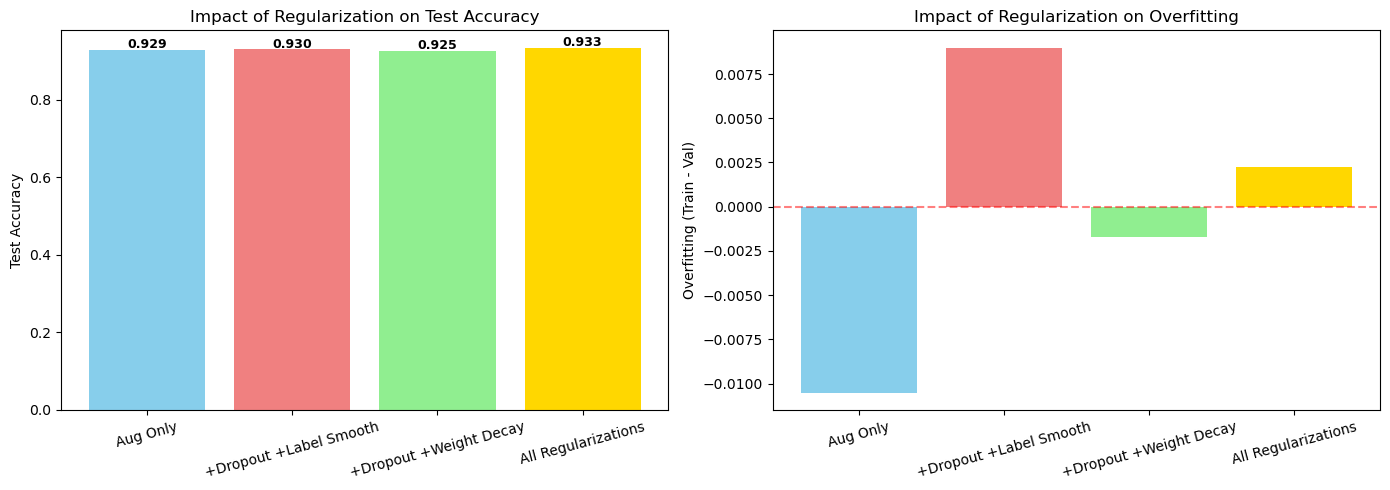

In [24]:
reg_df = pd.DataFrame([
    {
        'Method': 'Advanced Aug Only',
        'Label Smoothing': 'No',
        'Weight Decay': '0',
        'Val Acc': f"{results_list[1]['best_val_acc']:.4f}",
        'Test Acc': f"{results_list[1]['test_acc']:.4f}",
        'Overfitting': f"{results_list[1]['overfitting']:.4f}"
    },
    {
        'Method': '+ Label Smoothing',
        'Label Smoothing': 'Yes',
        'Weight Decay': '0',
        'Val Acc': f"{result4['best_val_acc']:.4f}",
        'Test Acc': f"{result4['test_acc']:.4f}",
        'Overfitting': f"{result4['overfitting']:.4f}"
    },
    {
        'Method': '+ Weight Decay',
        'Label Smoothing': 'No',
        'Weight Decay': '1e-4',
        'Val Acc': f"{result5['best_val_acc']:.4f}",
        'Test Acc': f"{result5['test_acc']:.4f}",
        'Overfitting': f"{result5['overfitting']:.4f}"
    },
    {
        'Method': '+ Both',
        'Label Smoothing': 'Yes',
        'Weight Decay': '1e-4',
        'Val Acc': f"{result6['best_val_acc']:.4f}",
        'Test Acc': f"{result6['test_acc']:.4f}",
        'Overfitting': f"{result6['overfitting']:.4f}"
    }
])

print('REGULARIZATION COMPARISON')
print(reg_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

methods = ['Aug Only', '+Dropout +Label Smooth', '+Dropout +Weight Decay', 'All Regularizations']
test_accs = [results_list[1]['test_acc'], result4['test_acc'],
             result5['test_acc'], result6['test_acc']]
overfits = [results_list[1]['overfitting'], result4['overfitting'],
            result5['overfitting'], result6['overfitting']]

axes[0].bar(methods, test_accs, color=['skyblue', 'lightcoral', 'lightgreen', 'gold'])
axes[0].set_ylabel('Test Accuracy')
axes[0].set_title('Impact of Regularization on Test Accuracy')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(test_accs):
    axes[0].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

axes[1].bar(methods, overfits, color=['skyblue', 'lightcoral', 'lightgreen', 'gold'])
axes[1].set_ylabel('Overfitting (Train - Val)')
axes[1].set_title('Impact of Regularization on Overfitting')
axes[1].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../results/regularization_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [17]:
print('TRAINING MODELS FOR ENSEMBLE')

ensemble_models = []
ensemble_results = []

configs = [
    {'name': 'resnet50', 'aug': 'advanced'}
]

for i, config in enumerate(configs):
    result = run_experiment(
        model_name=config['name'],
        augmentation_type=config['aug'],
        use_label_smoothing=True,
        weight_decay=1e-4,
        num_epochs=12,
        experiment_name=f"ensemble_model_{i+1}"
    )
    ensemble_results.append(result)

TRAINING MODELS FOR ENSEMBLE
Experiment: ensemble_model_1
Model: resnet50, Augmentation: advanced
Label Smoothing: True, Weight Decay: 0.0001


C:\Users\zhenu\anaconda3\envs\torch_gpu\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\zhenu\anaconda3\envs\torch_gpu\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/12] Train: 0.8558, Val: 0.9216
Epoch [2/12] Train: 0.9035, Val: 0.9448
Epoch [3/12] Train: 0.9173, Val: 0.9512
Epoch [4/12] Train: 0.9260, Val: 0.9558
Epoch [5/12] Train: 0.9365, Val: 0.9622
Epoch [6/12] Train: 0.9422, Val: 0.9555
Epoch [7/12] Train: 0.9420, Val: 0.9644
Epoch [8/12] Train: 0.9460, Val: 0.9733
Epoch [9/12] Train: 0.9517, Val: 0.9690
Epoch [10/12] Train: 0.9566, Val: 0.9633
Epoch [11/12] Train: 0.9605, Val: 0.9733
Epoch [12/12] Train: 0.9635, Val: 0.9779


C:\Users\zhenu\AppData\Local\Temp\ipykernel_1172\4257630073.py:85: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'../checkpoints/{experimen


Val: 0.9779, Test: 0.9333, Overfitting: -0.0144


In [26]:
def load_model_for_ensemble(checkpoint_path, model_name):
    model = TransferModel(model_name=model_name, num_classes=6, pretrained=False).to(device)
    state_dict = torch.load(checkpoint_path, map_location=device)

    new_state_dict = {}
    for key, value in state_dict.items():
        if key.startswith('base_model.base_model.'):
            new_key = key.replace('base_model.base_model.', 'base_model.')
            new_state_dict[new_key] = value
        else:
            new_state_dict[key] = value

    model.load_state_dict(new_state_dict)
    model.eval()
    return model

models_for_ensemble = [
    load_model_for_ensemble('../checkpoints/aug_baseline.pth', 'resnet18'),
    load_model_for_ensemble('../checkpoints/aug_advanced.pth', 'resnet18'),
    load_model_for_ensemble('../checkpoints/ensemble_model_1.pth', 'resnet50')
]

def ensemble_predict(models, loader, device):
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            batch_preds = []
            for model in models:
                outputs = model(images)
                probs = torch.softmax(outputs, dim=1)
                batch_preds.append(probs)

            avg_probs = torch.stack(batch_preds).mean(dim=0)
            predictions = avg_probs.argmax(dim=1)

            all_preds.extend(predictions.cpu().numpy())
            all_labels.extend(labels.numpy())

    correct = sum([p == l for p, l in zip(all_preds, all_labels)])
    accuracy = correct / len(all_labels)

    return accuracy, all_preds, all_labels

data_dir = '../dataSet/archive/seg_train/seg_train'
test_dir = '../dataSet/archive/seg_test/seg_test'

val_transform = BaselineTransform.get_transforms(224)
full_dataset = datasets.ImageFolder(data_dir, transform=val_transform)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
_, val_dataset = random_split(full_dataset, [train_size, val_size])
test_dataset = datasets.ImageFolder(test_dir, transform=val_transform)

val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

val_acc, _, _ = ensemble_predict(models_for_ensemble, val_loader, device)
test_acc, _, _ = ensemble_predict(models_for_ensemble, test_loader, device)

print('ENSEMBLE RESULTS')
print(f'\nEnsemble validation acc: {val_acc:.4f}')
print(f'Ensemble test acc: {test_acc:.4f}')

ensemble_improvement = test_acc - max([r['test_acc'] for r in results_list])
print(f'\nEnsemble improvement: +{ensemble_improvement:.4f}')

C:\Users\zhenu\AppData\Local\Temp\ipykernel_1172\2942759478.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_path, map_location=device)

ENSEMBLE RESULTS

Ensemble validation acc: 0.9882
Ensemble test acc: 0.9370

Ensemble improvement: +0.0040


In [35]:
final_comparison = pd.DataFrame([
    {
        'Experiment': 'Baseline Aug',
        'Augmentation': 'Baseline',
        'Regularization': 'None',
        'Type': 'Single',
        'Val Acc': f"{results_list[0]['best_val_acc']:.4f}",
        'Test Acc': f"{results_list[0]['test_acc']:.4f}",
        'Time (min)': f"{results_list[0]['training_time'] / 60:.2f}"
    },
    {
        'Experiment': 'Advanced Aug',
        'Augmentation': 'Advanced',
        'Regularization': 'None',
        'Type': 'Single',
        'Val Acc': f"{results_list[1]['best_val_acc']:.4f}",
        'Test Acc': f"{results_list[1]['test_acc']:.4f}",
        'Time (min)': f"{results_list[1]['training_time'] / 60:.2f}"
    },
    {
        'Experiment': 'Label Smoothing',
        'Augmentation': 'Advanced',
        'Regularization': 'Label Smooth+Dropout',
        'Type': 'Single',
        'Val Acc': f"{result4['best_val_acc']:.4f}",
        'Test Acc': f"{result4['test_acc']:.4f}",
        'Time (min)': f"{result4['training_time'] / 60:.2f}"
    },
    {
        'Experiment': 'Weight Decay',
        'Augmentation': 'Advanced',
        'Regularization': 'L2+Dropout',
        'Type': 'Single',
        'Val Acc': f"{result5['best_val_acc']:.4f}",
        'Test Acc': f"{result5['test_acc']:.4f}",
        'Time (min)': f"{result5['training_time'] / 60:.2f}"
    },
    {
        'Experiment': 'Combined Reg',
        'Augmentation': 'Advanced',
        'Regularization': 'All',
        'Type': 'Single',
        'Val Acc': f"{result6['best_val_acc']:.4f}",
        'Test Acc': f"{result6['test_acc']:.4f}",
        'Time (min)': f"{result6['training_time'] / 60:.2f}"

    },
    {
        'Experiment': 'Ensemble',
        'Augmentation': 'Mixed',
        'Regularization': 'Mixed',
        'Type': 'Ensemble',
        'Val Acc': f"{val_acc:.4f}",
        'Test Acc': f"{test_acc:.4f}",
        'Time (min)': f"Combined"
    }
])

print('COMPLETE AUGMENTATION & REGULARIZATION')
print(final_comparison.to_string(index=False))

final_comparison.to_csv('../results/augmentation_regularization.csv', index=False)

best_single = max(results_list + [result4, result5, result6], key=lambda x: x['test_acc'])
print(f"\n Best single model: {best_single['experiment']} - {best_single['test_acc']:.4f}")
print(f" Ensemble: {test_acc:.4f}")
print(f"Improvement from baseline: +{test_acc - results_list[0]['test_acc']:.4f}")

COMPLETE AUGMENTATION & REGULARIZATION
     Experiment Augmentation       Regularization     Type Val Acc Test Acc Time (min)
   Baseline Aug     Baseline                 None   Single  0.9804   0.9217       8.04
   Advanced Aug     Advanced                 None   Single  0.9669   0.9287      22.66
Label Smoothing     Advanced Label Smooth+Dropout   Single  0.9861   0.9303      11.46
   Weight Decay     Advanced           L2+Dropout   Single  0.9815   0.9253       7.66
   Combined Reg     Advanced                  All   Single  0.9900   0.9330      11.50
       Ensemble        Mixed                Mixed Ensemble  0.9882   0.9370   Combined

 Best single model: reg_combined - 0.9330
 Ensemble: 0.9370
Improvement from baseline: +0.0153
